# ⚙️ Notebook 2: Feature Engineering

## Learning Objectives
By the end of this notebook, you will:
- Understand what features are and why they matter
- Create technical indicators from price data
- Build a sentiment proxy
- Create the target variable for prediction
- Prepare data for machine learning

## What You'll Learn
- Rolling window calculations
- Technical analysis indicators
- Avoiding look-ahead bias
- Feature importance concepts

---

## What are Features?

**Features** are the input variables that a machine learning model uses to make predictions.

**Raw data** (Close price: $150) → **Features** (5-day average: $148, momentum: +$5) → **Model** → **Prediction** (Up/Down)

### Why Not Just Use Raw Prices?
- Absolute prices don't tell us about trends
- We need context: Is the price rising or falling?
- Features capture patterns that predict future movement

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
import config
from src.data_collection import load_stock_data
from src.preprocessing import preprocess_stock_data
from src import feature_engineering as fe

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Ready to engineer features!")

✅ Imported necessary libraries
✅ Imported config settings
✅ Ready to engineer features!


## Step 1: Load and Preprocess Data

In [2]:
# Load the data from Notebook 1
ticker = 'AAPL'
raw_data = load_stock_data(ticker, 'raw')

if raw_data is None:
    print("❌ Data not found. Please run Notebook 1 first!")
else:
    # Preprocess
    data = preprocess_stock_data(raw_data)
    print(f"✅ Loaded {len(data)} days of {ticker} data")
    print(f"Date range: {data['Date'].min()} to {data['Date'].max()}")
    
    # Show first few rows
    data.head()

✅ Loaded 251 rows from C:\Users\user\Desktop\Machine Learning Project\stock_ml_project\data\raw\AAPL_raw.csv

PREPROCESSING PIPELINE

Step 1: Cleaning data...
⚠️  Missing values found:
Date      1
Close     1
High      1
Low       1
Open      1
Volume    1
Ticker    1
dtype: int64

Step 2: Handling missing values...
Applied forward fill for missing values

Step 3: Validating data...
✅ Data validation passed

Preprocessing complete: 251 rows

✅ Loaded 251 days of AAPL data
Date range: 2023-01-03 00:00:00 to 2023-12-29 00:00:00


## Step 2: Feature 1 - Daily Returns

Returns show percentage change in price.

**Formula**: `(Today's Close - Yesterday's Close) / Yesterday's Close`

In [3]:
# Calculate returns
data = fe.calculate_returns(data)

# Visualize
print("Returns Statistics:")
print(f"Mean: {data['Returns'].mean():.4f}")
print(f"Std: {data['Returns'].std():.4f}")

# Show sample
data[['Date', 'Close', 'Returns']].head(10)

✅ Added 'Returns' feature
Returns Statistics:
Mean: 0.0018
Std: 0.0125


,Date,Close,Returns
0,2023-01-03,123.096008,NaN
1,2023-01-04,124.365654,0.010314
2,2023-01-05,123.046822,-0.010604
3,2023-01-06,127.574188,0.036794
4,2023-01-09,128.095840,0.004089
5,2023-01-10,128.666687,0.004456
6,2023-01-11,131.383133,0.021112
7,2023-01-12,131.304382,-0.000599
8,2023-01-13,132.633072,0.010119
9,2023-01-17,133.794449,0.008756


## Step 3: Feature 2 - Moving Averages

Moving averages smooth out price fluctuations to show trends.

- **SMA_5**: Average of last 5 days (short-term trend)
- **SMA_20**: Average of last 20 days (long-term trend)

**Trading signal**: When short-term > long-term, it's a bullish signal!

✅ Added 'SMA_5' feature
✅ Added 'SMA_10' feature
✅ Added 'SMA_20' feature


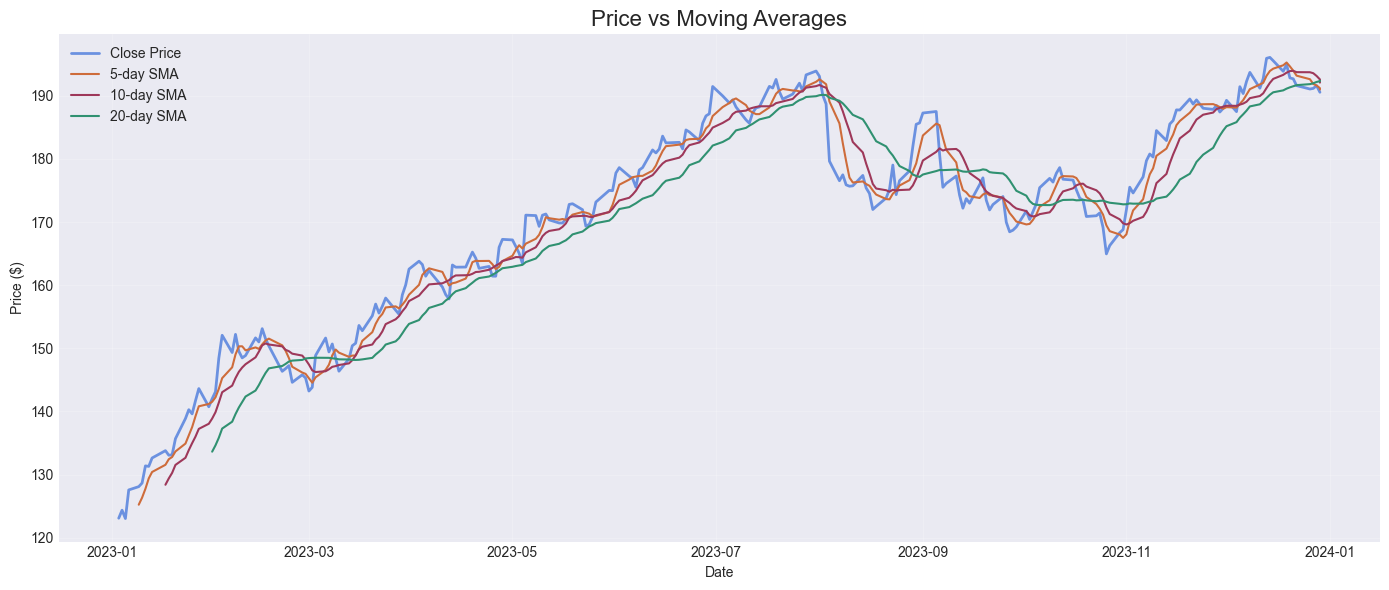


💡 Notice how moving averages smooth out daily noise!
When SMA_5 crosses above SMA_20, it often signals an uptrend.


In [4]:
# Add moving averages
data = fe.add_rolling_averages(data, windows=[5, 10, 20])

# Visualize
plt.figure(figsize=(14, 6))
plt.plot(data['Date'], data['Close'], label='Close Price', linewidth=2, alpha=0.7)
plt.plot(data['Date'], data['SMA_5'], label='5-day SMA', linewidth=1.5)
plt.plot(data['Date'], data['SMA_10'], label='10-day SMA', linewidth=1.5)
plt.plot(data['Date'], data['SMA_20'], label='20-day SMA', linewidth=1.5)
plt.title('Price vs Moving Averages', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Notice how moving averages smooth out daily noise!")
print("When SMA_5 crosses above SMA_20, it often signals an uptrend.")

## Step 4: Feature 3 - Volatility

Volatility measures how much the price fluctuates.

**Formula**: Standard deviation of returns over a rolling window

✅ Added 'Volatility' feature (window=20)


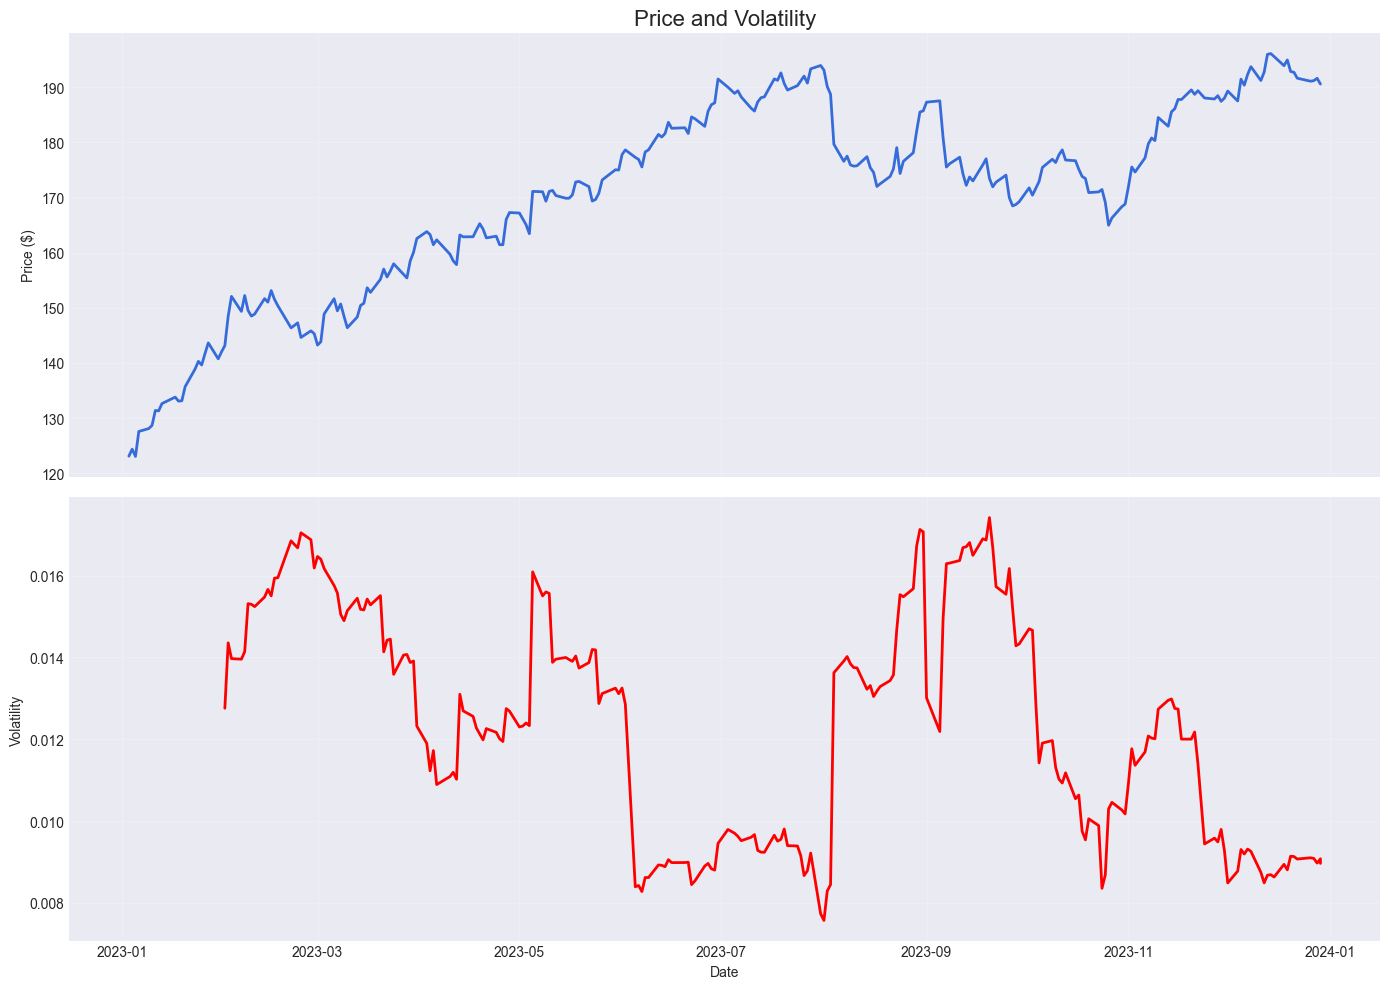


💡 High volatility = more uncertainty = harder to predict!


In [5]:
# Calculate volatility
data = fe.calculate_volatility(data, window=20)

# Visualize
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Price
ax1.plot(data['Date'], data['Close'], linewidth=2)
ax1.set_title('Price and Volatility', fontsize=16)
ax1.set_ylabel('Price ($)')
ax1.grid(True, alpha=0.3)

# Volatility
ax2.plot(data['Date'], data['Volatility'], color='red', linewidth=2)
ax2.set_xlabel('Date')
ax2.set_ylabel('Volatility')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 High volatility = more uncertainty = harder to predict!")

## Step 5: More Features

Let's add several more features at once:

In [6]:
# Add all remaining features
data = fe.calculate_momentum(data)
data = fe.calculate_volume_change(data)
data = fe.calculate_hl_spread(data)

print("Added features:")
print("- Momentum: Price change over N days")
print("- Volume_Change: Change in trading volume")
print("- HL_Spread: High-Low range normalized")

# Show current columns
print(f"\nTotal columns now: {len(data.columns)}")
print(f"Columns: {list(data.columns)}")

✅ Added 'Momentum' feature (window=5)
✅ Added 'Volume_Change' feature
✅ Added 'HL_Spread' feature
Added features:
- Momentum: Price change over N days
- Volume_Change: Change in trading volume
- HL_Spread: High-Low range normalized

Total columns now: 15
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Returns', 'SMA_5', 'SMA_10', 'SMA_20', 'Volatility', 'Momentum', 'Volume_Change', 'HL_Spread']


## Step 6: Sentiment Proxy

We create a price-based sentiment indicator as a proxy for market sentiment.

This is a simplified version. In reality, you'd use NLP on news articles!

✅ Added 'Sentiment_Proxy' feature
✅ Added 'Sentiment_SMA' feature (window=3)


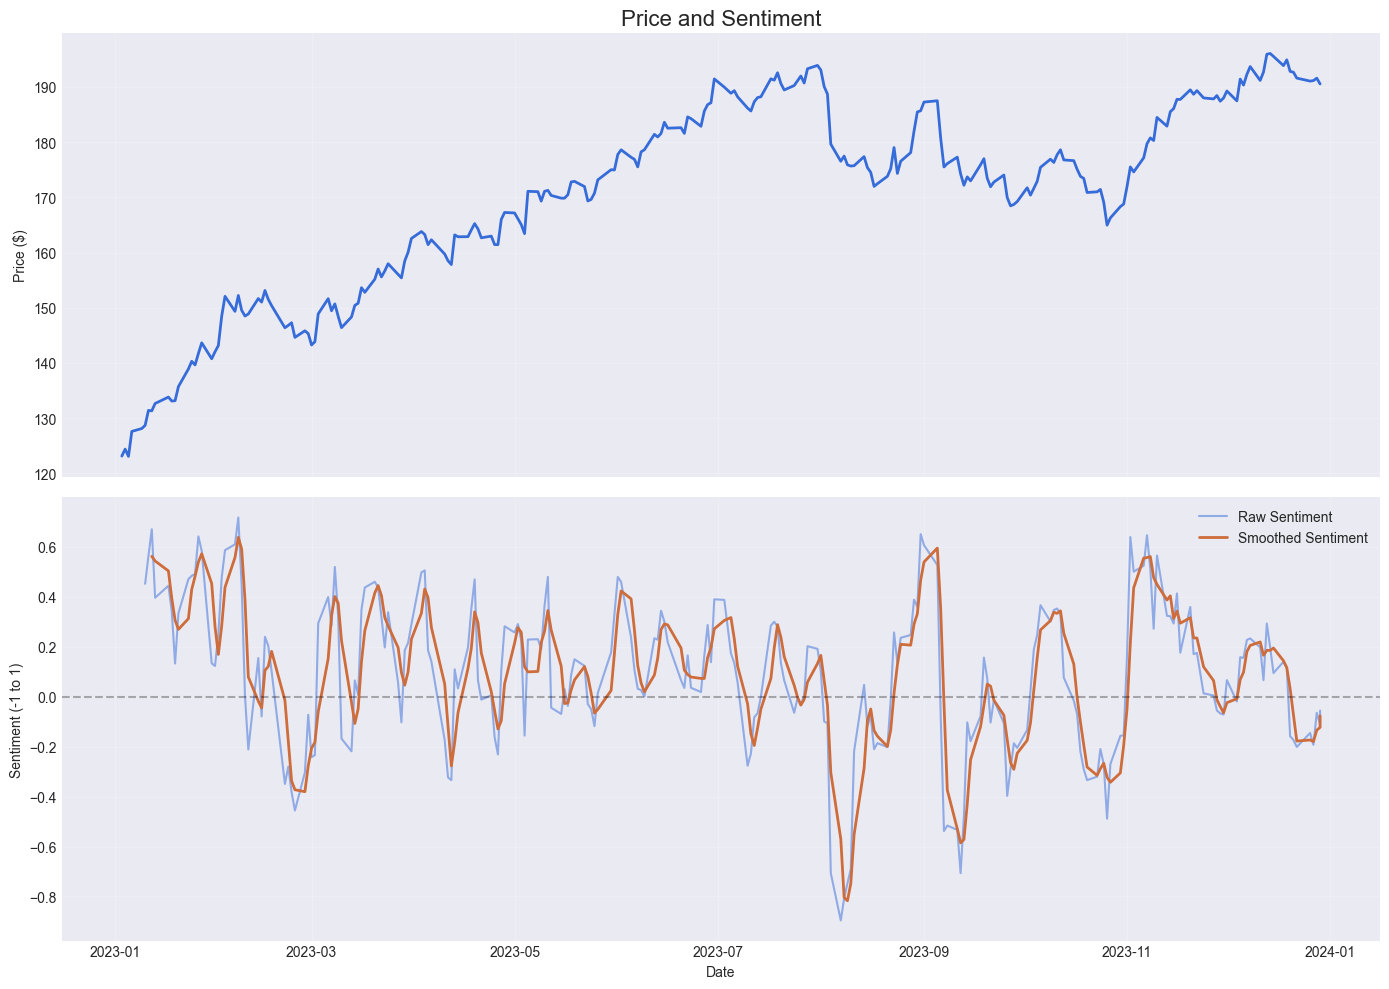


💡 Positive sentiment (>0) often correlates with price increases!


In [7]:
# Create sentiment features
data = fe.create_sentiment_proxy(data)
data = fe.smooth_sentiment(data)

# Visualize sentiment
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Price
ax1.plot(data['Date'], data['Close'], linewidth=2)
ax1.set_title('Price and Sentiment', fontsize=16)
ax1.set_ylabel('Price ($)')
ax1.grid(True, alpha=0.3)

# Sentiment
ax2.plot(data['Date'], data['Sentiment_Proxy'], alpha=0.5, label='Raw Sentiment')
ax2.plot(data['Date'], data['Sentiment_SMA'], linewidth=2, label='Smoothed Sentiment')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax2.set_xlabel('Date')
ax2.set_ylabel('Sentiment (-1 to 1)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Positive sentiment (>0) often correlates with price increases!")

## Step 7: THE TARGET VARIABLE ⚠️

This is what we're trying to predict!

**Target = 1** if tomorrow's price > today's price (UP)
**Target = 0** if tomorrow's price ≤ today's price (DOWN)

### CRITICAL: Avoiding Look-Ahead Bias
We use `.shift(-1)` to get tomorrow's price. This creates NaN in the last row because there's no "tomorrow" data yet!

✅ Added 'Target' variable (horizon=1 day)
   Last 1 row(s) will have NaN target
Target Variable Examples:
          Date       Close  Future_Close  Target
241 2023-12-18  193.875931    194.915131       1
242 2023-12-19  194.915131    192.826859       0
243 2023-12-20  192.826859    192.678360       0
244 2023-12-21  192.678360    191.609497       0
245 2023-12-22  191.609497    191.065125       0
246 2023-12-26  191.065125    191.164093       1
247 2023-12-27  191.164093    191.589691       1
248 2023-12-28  191.589691    190.550461       0
249 2023-12-29  190.550461    190.550461       0
250 2023-12-29  190.550461           NaN       0

Target Distribution:
Down (0): 111 days
Up (1): 140 days


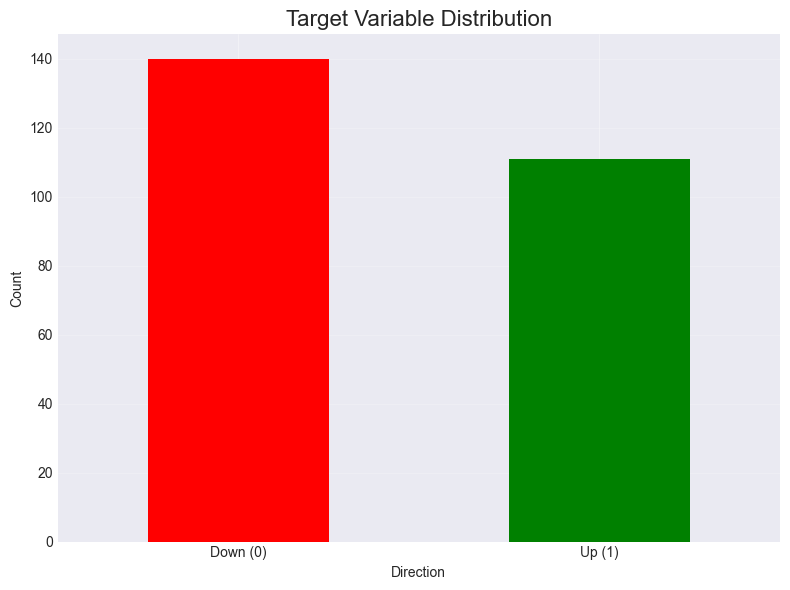

In [8]:
# Create target variable
data = fe.create_target_variable(data, horizon=1)

# Show examples
print("Target Variable Examples:")
print("="*70)
sample = data[['Date', 'Close', 'Future_Close', 'Target']].tail(10)
print(sample)

# Distribution
target_counts = data['Target'].value_counts()
print(f"\nTarget Distribution:")
print(f"Down (0): {target_counts.get(0, 0)} days")
print(f"Up (1): {target_counts.get(1, 0)} days")

# Visualize
plt.figure(figsize=(8, 6))
data['Target'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Target Variable Distribution', fontsize=16)
plt.xlabel('Direction')
plt.ylabel('Count')
plt.xticks([0, 1], ['Down (0)', 'Up (1)'], rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Step 8: Feature Correlation Analysis

Let's see which features correlate with our target variable!

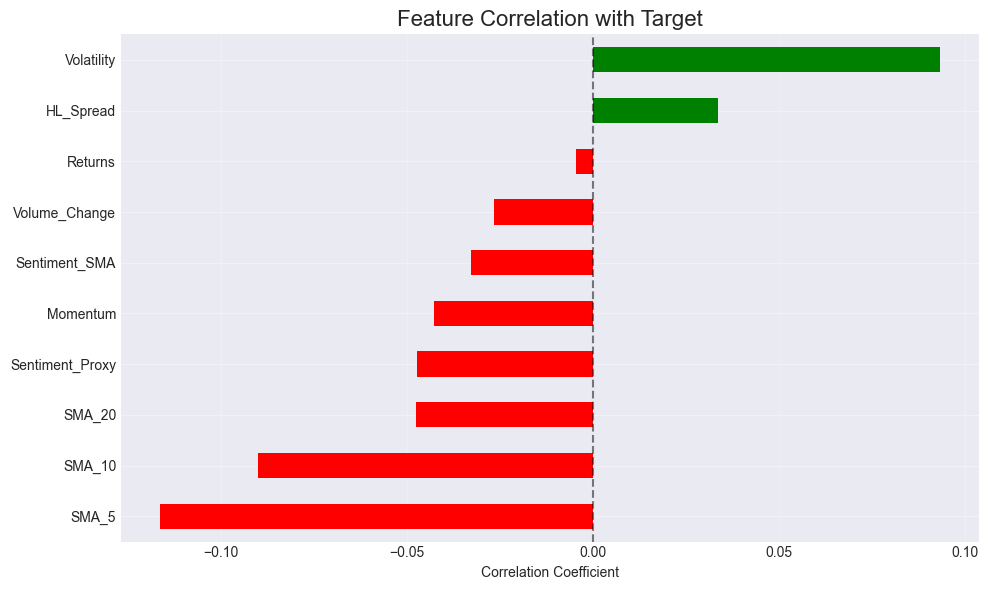


💡 Features with higher correlation are more predictive!

Strongest positive correlation: Volatility (0.0932)
Strongest negative correlation: SMA_5 (-0.1164)


In [9]:
# Calculate correlations with target
feature_cols = ['Returns', 'SMA_5', 'SMA_10', 'SMA_20', 'Volatility', 
                'Momentum', 'Volume_Change', 'HL_Spread', 
                'Sentiment_Proxy', 'Sentiment_SMA']

correlations = data[feature_cols + ['Target']].corr()['Target'].drop('Target').sort_values()

# Visualize
plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color=['red' if x < 0 else 'green' for x in correlations])
plt.title('Feature Correlation with Target', fontsize=16)
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n💡 Features with higher correlation are more predictive!")
print(f"\nStrongest positive correlation: {correlations.idxmax()} ({correlations.max():.4f})")
print(f"Strongest negative correlation: {correlations.idxmin()} ({correlations.min():.4f})")

## Step 9: Prepare Data for Machine Learning

In [10]:
# Prepare ML data
X, y, feature_names = fe.prepare_ml_data(data)

print("\n🎯 Data Ready for Machine Learning!")
print("="*70)
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nFeature names: {feature_names}")

# Show sample
print("\nSample of prepared data:")
sample_df = pd.DataFrame(X, columns=feature_names).head()
sample_df['Target'] = y.head().values
sample_df

Dropped 21 rows with NaN values
Usable data: 230 rows

Features (15): ['Close', 'High', 'Low', 'Open', 'Volume', 'Returns', 'SMA_5', 'SMA_10', 'SMA_20', 'Volatility', 'Momentum', 'Volume_Change', 'HL_Spread', 'Sentiment_Proxy', 'Sentiment_SMA']
X shape: (230, 15)
y shape: (230,)

Target distribution:
Target
1    125
0    105
Name: count, dtype: int64
Percentage Up: 54.3%

🎯 Data Ready for Machine Learning!
Features (X): (230, 15)
Target (y): (230,)

Feature names: ['Close', 'High', 'Low', 'Open', 'Volume', 'Returns', 'SMA_5', 'SMA_10', 'SMA_20', 'Volatility', 'Momentum', 'Volume_Change', 'HL_Spread', 'Sentiment_Proxy', 'Sentiment_SMA']

Sample of prepared data:


,Close,High,Low,Open,Volume,Returns,SMA_5,SMA_10,SMA_20,Volatility,Momentum,Volume_Change,HL_Spread,Sentiment_Proxy,Sentiment_SMA,Target
20,143.134674,144.296058,139.089557,141.697726,77663600.0,0.007901,142.241010,139.881836,134.637928,0.012758,3.513657,0.178963,0.036375,0.251657,0.169694,1
21,148.439621,148.793925,145.831437,146.549911,118339000.0,0.037063,143.591357,141.412296,135.841626,0.014354,6.751740,0.523738,0.019958,0.476522,0.283888,1
22,152.061523,154.896073,145.496798,145.693638,154357300.0,0.024400,145.278308,143.049049,137.292361,0.013969,8.434753,0.304365,0.061812,0.587269,0.438483,0
23,149.335236,150.683623,148.400232,150.161989,69858300.0,-0.017929,146.996747,144.094289,138.380414,0.013955,8.592194,-0.547425,0.015290,0.610488,0.558093,1
24,152.209152,152.780000,148.262447,148.262447,83322600.0,0.019245,149.036041,145.287160,139.586079,0.014142,10.196472,0.192737,0.029680,0.717997,0.638585,0


## Step 10: Save Engineered Features

In [11]:
# Save to CSV
output_path = config.get_data_path(ticker, 'features')
data.to_csv(output_path, index=False)
print(f"✅ Saved engineered features to: {output_path}")

print("\n📊 Summary:")
print(f"Original columns: 7 (Date, Open, High, Low, Close, Volume, Ticker)")
print(f"Final columns: {len(data.columns)}")
print(f"New features created: {len(data.columns) - 7}")

✅ Saved engineered features to: C:\Users\user\Desktop\Machine Learning Project\stock_ml_project\data\features\AAPL_features.csv

📊 Summary:
Original columns: 7 (Date, Open, High, Low, Close, Volume, Ticker)
Final columns: 19
New features created: 12


## 🎯 Exercise: Create Your Own Feature!

Try implementing the **Relative Strength Index (RSI)**:

RSI measures the speed and magnitude of price changes.
- RSI > 70: Overbought (might go down)
- RSI < 30: Oversold (might go up)

In [ ]:
# YOUR CODE HERE
# Implement RSI calculation

def calculate_rsi(data, window=14):
    """
    Calculate Relative Strength Index
    
    Hint:
    1. Calculate price changes (delta)
    2. Separate gains and losses
    3. Calculate average gain and average loss
    4. RS = average gain / average loss
    5. RSI = 100 - (100 / (1 + RS))
    """
    # Your implementation here
    pass

# Test it
# data['RSI'] = calculate_rsi(data)
# Plot it alongside price

## 📝 Key Takeaways

1. **Features** transform raw data into predictive signals
2. **Rolling windows** capture trends over time
3. **Technical indicators** (SMA, volatility) are proven predictive features
4. **Target variable** is binary: up (1) or down (0)
5. **Look-ahead bias** is a common mistake - never use future data!
6. **Feature correlation** helps identify the most predictive variables

## Next Steps

In Notebook 3, we'll train a Random Forest model using these features!

---

**Questions to think about:**
- Why do moving averages work as predictive features?
- What other features could we create from price and volume?
- How might we incorporate news sentiment in the future?